# Reproducibility_Astro — Analysis Notebook

Analyses results from the Reproducibility_Astro pipeline across four research questions,
with full RRS ablation analysis following Sheeba Samuel's ReproScore framework.

**Research questions:**
1. **RQ1** — How are Jupyter notebooks *referenced* in astrophysics publications?
2. **RQ2** — How *stable* are those referenced notebooks? (RRS scoring + ablation)
3. **RQ3** — Where are notebooks *hosted*?
4. **RQ4** — How do notebooks *receive citations*?

**Prerequisites:** Run `collect.sh`, then `run.sh` (batch mode).  
**DB:** `output/db/db.sqlite`

In [19]:
import os, sys, subprocess
from pathlib import Path

cwd = Path.cwd()
repo_root = cwd.parent if cwd.name == 'analysis' else cwd
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))
print(f'Repo root: {repo_root}')

DB_PATH = repo_root / 'output' / 'db' / 'db.sqlite'
assert DB_PATH.exists(), f'DB not found at {DB_PATH}'
print(f'DB: {DB_PATH}')

Repo root: /home/jovyan
DB: /home/jovyan/output/db/db.sqlite


In [20]:
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'pandas>=1.5.0', 'numpy>=1.23.0', 'scipy>=1.10.0',
    'matplotlib>=3.6.0', 'seaborn>=0.12.0'], stdout=subprocess.DEVNULL)

import sqlite3, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
sns.set_theme(style='whitegrid')
FIGURES = repo_root / 'analysis' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

def load(sql, **kwargs):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn, **kwargs)

CATS = [('E', 0.30, 40, 1.5), ('A', 0.25, 30, 1.5),
        ('D', 0.20, 20, 1.2), ('C', 0.15, 25, 1.2), ('S', 0.10, 30, 1.2)]
CAT_NAMES = {'E': 'Environment', 'A': 'Data Access.',
             'D': 'Documentation', 'C': 'Code Quality', 'S': 'Repro. Signals'}
FAILURE_MODES = ['success', 'install_dep', 'missing_module', 'missing_data', 'code_error']
MODE_COLORS = {'success': '#2ecc71', 'install_dep': '#e74c3c',
               'missing_module': '#e67e22', 'missing_data': '#3498db', 'code_error': '#9b59b6'}

def auc_mwu(scores, labels):
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=int)
    pos, neg = scores[labels == 1], scores[labels == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float('nan')
    u = sum((p > neg).sum() + 0.5 * (p == neg).sum() for p in pos)
    return float(u) / (len(pos) * len(neg))

def gate(x, tau, k):
    x = np.asarray(x, dtype=float)
    return np.where(x >= tau, x / 100.0, (x / tau) ** k * tau / 100.0)

print('Ready.')

Ready.


In [21]:
# DB overview
with sqlite3.connect(DB_PATH) as conn:
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
print('Tables in DB:')
for t in tables['name']:
    count = load(f'SELECT COUNT(*) AS n FROM "{t}"')['n'][0]
    print(f'  {t:<40} {count:>6} rows')

Tables in DB:
  article                                     102 rows
  author                                     1822 rows
  journal                                      18 rows
  notebook_executions                          12 rows
  notebook_mentions                            40 rows
  notebook_reproducibility_metrics             12 rows
  notebooks                                    12 rows
  repo_targets                                  3 rows
  repositories                                191 rows
  repository_runs                               3 rows
  sqlite_sequence                              10 rows


## RQ1 — How are notebooks referenced in publications?

Total articles: 102
         notebook_category  count  pct
              jupyter_only     80 78.4
       jupyter_with_github      9  8.8
       jupyter_with_zenodo      7  6.9
     jupyter_with_personal      4  3.9
jupyter_with_github_zenodo      2  2.0


/tmp/ipykernel_21427/3605597917.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_df, x='count', y='notebook_category', ax=ax, palette='Blues_d')


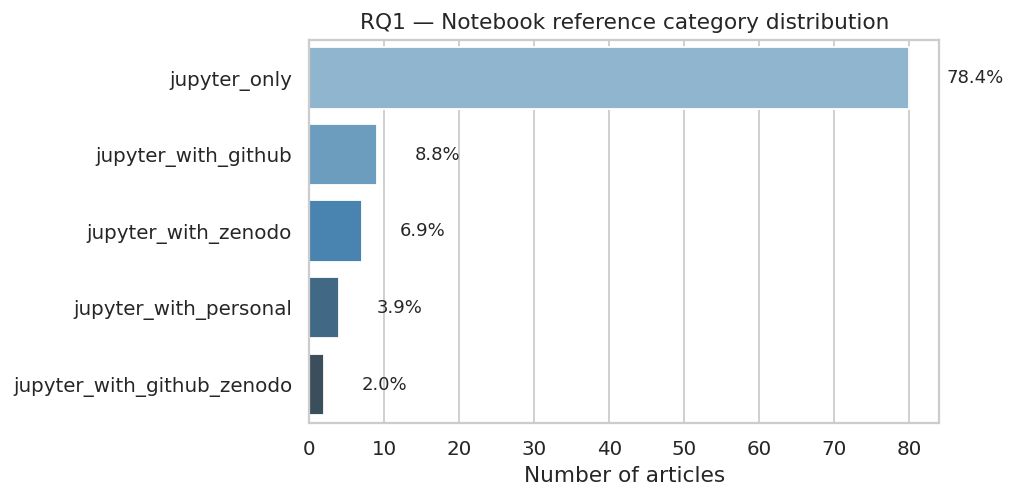

In [22]:
cat_df = load("""
    SELECT notebook_category, COUNT(*) AS count
    FROM article WHERE notebook_category IS NOT NULL
    GROUP BY notebook_category ORDER BY count DESC
""")
total_articles = cat_df['count'].sum()
cat_df['pct'] = (cat_df['count'] / total_articles * 100).round(1)
print(f'Total articles: {total_articles}')
print(cat_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=cat_df, x='count', y='notebook_category', ax=ax, palette='Blues_d')
for i, (count, pct) in enumerate(zip(cat_df['count'], cat_df['pct'])):
    ax.text(count + 5, i, f'{pct}%', va='center', fontsize=10)
ax.set_xlabel('Number of articles')
ax.set_ylabel('')
ax.set_title('RQ1 — Notebook reference category distribution')
plt.tight_layout()
plt.savefig(FIGURES / 'rq1_notebook_categories.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_21427/99890235.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=section_df, x='count', y='section', ax=axes[0], palette='Greens_d')
/tmp/ipykernel_21427/99890235.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=linkform_df, x='count', y='link_form', ax=axes[1], palette='Oranges_d')


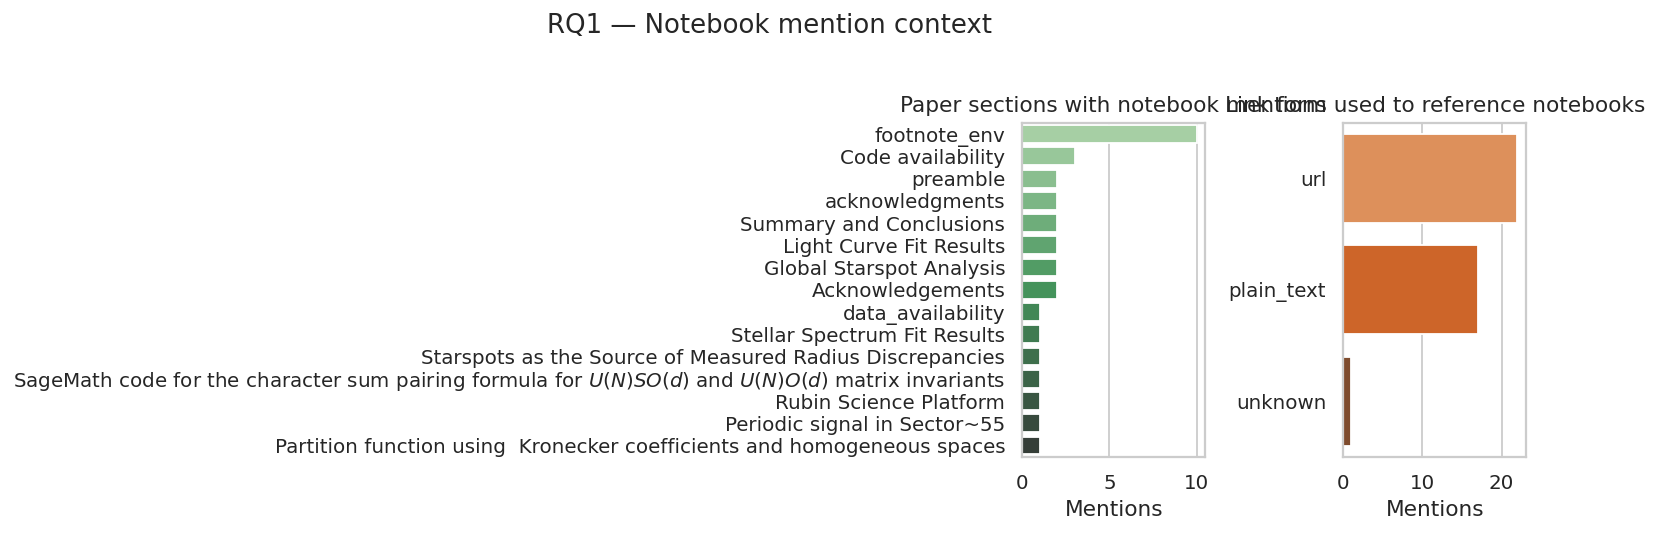

In [23]:
section_df = load("""
    SELECT COALESCE(section, 'unknown') AS section, COUNT(*) AS count
    FROM notebook_mentions GROUP BY section ORDER BY count DESC LIMIT 15
""")
linkform_df = load("""
    SELECT COALESCE(link_form, 'unknown') AS link_form, COUNT(*) AS count
    FROM notebook_mentions GROUP BY link_form ORDER BY count DESC
""")

if len(section_df) == 0:
    print('No notebook_mentions yet — run: bash mentions.sh')
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=section_df, x='count', y='section', ax=axes[0], palette='Greens_d')
    axes[0].set_title('Paper sections with notebook mentions')
    axes[0].set_xlabel('Mentions')
    axes[0].set_ylabel('')
    sns.barplot(data=linkform_df, x='count', y='link_form', ax=axes[1], palette='Oranges_d')
    axes[1].set_title('Link form used to reference notebooks')
    axes[1].set_xlabel('Mentions')
    axes[1].set_ylabel('')
    plt.suptitle('RQ1 — Notebook mention context', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES / 'rq1_mention_context.png', bbox_inches='tight')
    plt.show()

## RQ2 — How stable are referenced notebooks? (RRS + Ablation)

In [24]:
with sqlite3.connect(DB_PATH) as conn:
    has_targets = conn.execute(
        "SELECT COUNT(*) FROM sqlite_master WHERE type='table' AND name='repo_targets'"
    ).fetchone()[0]

if not has_targets:
    print('repo_targets table not found — run run.sh first.')
    df = pd.DataFrame()
else:
    df = load('SELECT * FROM repo_targets WHERE rrs IS NOT NULL')
    print(f'Scored repos: {len(df)}')
    df['failure_mode'] = 'unknown'
    y = (df['failure_mode'] == 'success').astype(int)
    print(df[['repository', 'rrs', 'score_E', 'score_A', 'score_D', 'score_C', 'score_S']].to_string(index=False))

Scored repos: 3
                      repository   rrs  score_E  score_A  score_D  score_C  score_S
      caravangelo/inflation-easy 24.71      5.0     34.0   67.565   91.250     84.8
                alecarones/broom 13.20     25.0      0.0   35.845   78.125     33.8
KevinMcK95/gaia_roman_astrometry  9.63      5.0     30.0    9.080   93.000     61.0


In [ ]:
# RRS score distribution
if len(df) == 0:
    print('No scored repos yet.')
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df['rrs'], bins=max(5, len(df)//2), color='steelblue', edgecolor='white')
    ax.axvline(df['rrs'].mean(), color='#e74c3c', linestyle='--',
               label=f'Mean = {df["rrs"].mean():.1f}')
    ax.set_xlabel('RRS score (0–100)')
    ax.set_ylabel('Number of repos')
    ax.set_title('RQ2 — RRS score distribution')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES / 'rq2_rrs_distribution.png', bbox_inches='tight')
    plt.show()
    print(df[['rrs','score_E','score_A','score_D','score_C','score_S']].describe().round(1))

In [ ]:
# Per-category mean scores
if len(df) > 0:
    cat_scores = df[['score_E','score_A','score_D','score_C','score_S']].mean().reset_index()
    cat_scores.columns = ['category', 'mean_score']
    cat_scores['label'] = cat_scores['category'].str.replace('score_', '').map(CAT_NAMES)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.barplot(data=cat_scores, x='mean_score', y='label', ax=axes[0], palette='RdYlGn')
    axes[0].set_xlabel('Mean score (0–100)')
    axes[0].set_ylabel('')
    axes[0].set_title('Mean RRS sub-scores by category')
    axes[0].axvline(50, color='grey', linestyle='--', linewidth=0.8)

    score_long = df[['score_E','score_A','score_D','score_C','score_S']].melt(
        var_name='Category', value_name='Score')
    score_long['Category'] = score_long['Category'].str.replace('score_', '').map(CAT_NAMES)
    if len(df) >= 5:
        sns.violinplot(data=score_long, x='Category', y='Score', ax=axes[1], palette='pastel')
    else:
        sns.stripplot(data=score_long, x='Category', y='Score', ax=axes[1], jitter=True, size=10)
    axes[1].set_title('Score distributions per category')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=20)
    plt.suptitle('RQ2 — RRS Category Analysis', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES / 'rq2_rrs_subcategories.png', bbox_inches='tight')
    plt.show()

In [ ]:
# Simple baselines — single-category AUC (needs mixed outcomes)
if len(df) >= 4 and y.sum() > 0 and y.sum() < len(y):
    print('Simple baselines (AUC for binary success prediction):')
    print(f'  Random classifier          : 0.500')
    for c, *_ in CATS:
        col = f'score_{c}'
        if col in df.columns:
            a = auc_mwu(df[col], y)
            print(f'  {CAT_NAMES[c]:<25}: {a:.3f}')
    print(f'  Full RRS                   : {auc_mwu(df["rrs"], y):.3f}')
else:
    print(f'AUC baselines need mixed outcomes — have {len(df)} repos, {int(y.sum())} successes.')
    print('Run more repos to enable this analysis.')

In [ ]:
# Rank stability under ±50% weight perturbation (Table 4)
if len(df) >= 5:
    base_ranks = df['rrs'].rank()
    rows = []
    for cat, default_w, t, k in CATS:
        col = f'score_{cat}'
        if col not in df.columns: continue
        tau_vals = []
        for mult in np.linspace(0.5, 1.5, 20):
            new_w = default_w * mult
            others_scale = (1.0 - new_w) / (1.0 - default_w) if (1.0 - default_w) != 0 else 1.0
            w_scaled = {c: (w * others_scale if c != cat else new_w) for c, w, *__ in CATS}
            g_score = sum(w_scaled[c] * gate(df[f'score_{c}'], tt, kk) * 100
                         for c, _w, tt, kk in CATS if f'score_{c}' in df.columns)
            tau_val, _ = stats.kendalltau(base_ranks, np.clip(g_score, 0, 100))
            tau_vals.append(tau_val)
        rows.append({'Category': f'{cat} — {CAT_NAMES[cat]}',
                     'Min τ': round(min(tau_vals), 3),
                     'Mean τ': round(np.mean(tau_vals), 3),
                     'Max τ': round(max(tau_vals), 3)})
    table4 = pd.DataFrame(rows).set_index('Category')
    print('Table 4: Rank stability under ±50% weight perturbation')
    print(table4.to_string())
else:
    print(f'Rank stability needs ≥5 scored repos (have {len(df)}).')

In [ ]:
# LOCO — Leave-One-Category-Out analysis (Table 5)
if len(df) >= 4 and y.sum() > 0 and y.sum() < len(y):
    full_auc = auc_mwu(df['rrs'], y)
    loco_rows = [{'Removed': 'None (full model)', 'AUC': full_auc, 'ΔAUC': float('nan')}]
    for cat, default_w, t, k in CATS:
        remaining = [(c, w, tt, kk) for c, w, tt, kk in CATS if c != cat]
        w_sum = sum(w for _, w, _, _ in remaining)
        loco_score = sum((w / w_sum) * gate(df[f'score_{c}'], tt, kk) * 100
                         for c, w, tt, kk in remaining if f'score_{c}' in df.columns)
        loco_auc = auc_mwu(loco_score, y)
        loco_rows.append({'Removed': f'−{cat} ({CAT_NAMES[cat]})',
                          'AUC': round(loco_auc, 3), 'ΔAUC': round(loco_auc - full_auc, 3)})
    table5 = pd.DataFrame(loco_rows).set_index('Removed')
    print('Table 5: LOCO analysis (positive ΔAUC = removing category improves AUC)')
    print(table5.to_string())
else:
    print('LOCO needs mixed success/failure outcomes — run more repos.')

In [ ]:
# Top and bottom repos by RRS
if len(df) > 0:
    ranked = df.sort_values('rrs', ascending=False)
    cols = ['repository', 'rrs', 'score_E', 'score_A', 'score_D', 'score_C', 'score_S']
    print('--- Top repos by RRS ---')
    print(ranked[cols].head(10).to_string(index=False))
    if len(ranked) > 5:
        print()
        print('--- Bottom repos by RRS ---')
        print(ranked[cols].tail(5).to_string(index=False))

## RQ3 — Where are notebooks hosted?

In [ ]:
host_df = load("""
    SELECT COALESCE(host_type, 'unknown') AS host_type, COUNT(*) AS count
    FROM repositories GROUP BY host_type ORDER BY count DESC
""")
hosting_cat = load("""
    SELECT notebook_category, COUNT(*) AS count
    FROM article WHERE notebook_category IS NOT NULL
    GROUP BY notebook_category ORDER BY count DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].pie(host_df['count'], labels=host_df['host_type'],
            autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[0].set_title('Hosting platforms')
sns.barplot(data=hosting_cat, x='count', y='notebook_category', ax=axes[1], palette='Blues_d')
axes[1].set_title('Article notebook_category')
axes[1].set_xlabel('Articles')
axes[1].set_ylabel('')
plt.suptitle('RQ3 — Notebook hosting', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'rq3_hosting.png', bbox_inches='tight')
plt.show()

In [ ]:
# Hosting by arXiv subfield — stacked bar
subfield_host = load("""
    SELECT a.subject, a.notebook_category, COUNT(*) AS count
    FROM article a
    WHERE a.subject IS NOT NULL AND a.notebook_category IS NOT NULL
    GROUP BY a.subject, a.notebook_category ORDER BY a.subject, count DESC
""")
if len(subfield_host) > 0:
    pivot = subfield_host.pivot_table(
        index='subject', columns='notebook_category', values='count', fill_value=0)
    fig, ax = plt.subplots(figsize=(10, max(4, len(pivot)*0.4)))
    pivot.plot(kind='barh', stacked=True, ax=ax, colormap='tab10')
    ax.set_title('RQ3 — Hosting category by arXiv subfield')
    ax.set_xlabel('Number of articles')
    ax.set_ylabel('arXiv category')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES / 'rq3_hosting_by_subfield.png', bbox_inches='tight')
    plt.show()

## RQ4 — How do notebooks receive citations?

In [ ]:
doi_df = load("""
    SELECT CASE WHEN doi IS NOT NULL AND doi != '' THEN 'Has DOI' ELSE 'No DOI' END AS doi_status,
           COUNT(*) AS count FROM article GROUP BY doi_status
""")
zenodo_df = load("""
    SELECT CASE WHEN notebook_category LIKE '%zenodo%' THEN 'Has Zenodo' ELSE 'No Zenodo' END AS zenodo_status,
           COUNT(*) AS count FROM article WHERE notebook_category IS NOT NULL GROUP BY zenodo_status
""")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].pie(doi_df['count'], labels=doi_df['doi_status'],
            autopct='%1.1f%%', colors=['#4CAF50','#F44336'])
axes[0].set_title('Article DOI presence')
axes[1].pie(zenodo_df['count'], labels=zenodo_df['zenodo_status'],
            autopct='%1.1f%%', colors=['#2196F3','#9E9E9E'])
axes[1].set_title('Zenodo archiving (citable notebooks)')
plt.suptitle('RQ4 — Citation infrastructure', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'rq4_citation_infrastructure.png', bbox_inches='tight')
plt.show()
print(doi_df.to_string(index=False))
print(zenodo_df.to_string(index=False))

In [ ]:
# Publication year trend
year_df = load("""
    SELECT SUBSTR(a.published_date, 1, 4) AS year, a.notebook_category, COUNT(*) AS count
    FROM article a WHERE a.published_date IS NOT NULL
    GROUP BY year, a.notebook_category ORDER BY year
""")
if len(year_df) > 0:
    pivot = year_df.pivot_table(index='year', columns='notebook_category',
                                 values='count', fill_value=0)
    fig, ax = plt.subplots(figsize=(10, 4))
    pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_title('RQ4 — Notebook hosting category by publication year')
    ax.set_xlabel('Year')
    ax.set_ylabel('Articles')
    ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES / 'rq4_year_trend.png', bbox_inches='tight')
    plt.show()

In [ ]:
# DOI vs RRS
if has_targets and len(df) > 0:
    doi_exec = load("""
        SELECT CASE WHEN paper_doi IS NOT NULL AND paper_doi != '' THEN 'Has DOI' ELSE 'No DOI' END AS doi_status,
               COUNT(*) AS count, ROUND(AVG(rrs),1) AS avg_rrs,
               ROUND(MIN(rrs),1) AS min_rrs, ROUND(MAX(rrs),1) AS max_rrs
        FROM repo_targets WHERE rrs IS NOT NULL GROUP BY doi_status
    """)
    print('RQ4 — DOI presence vs RRS score:')
    print(doi_exec.to_string(index=False))

## Summary

In [ ]:
n_articles = load('SELECT COUNT(*) AS n FROM article')['n'][0]
n_repos    = load('SELECT COUNT(*) AS n FROM repositories')['n'][0]
n_mentions = load('SELECT COUNT(*) AS n FROM notebook_mentions')['n'][0]
n_scored   = len(df) if has_targets else 0

print('=' * 55)
print('PIPELINE SUMMARY')
print('=' * 55)
print(f'Articles collected          : {n_articles}')
print(f'Repositories found          : {n_repos}')
print(f'Notebook mentions extracted : {n_mentions}')
print(f'Repos scored (RRS)          : {n_scored}')
if n_scored > 0:
    print(f'Mean RRS                    : {df["rrs"].mean():.1f}')
    print(f'Min / Max RRS               : {df["rrs"].min():.1f} / {df["rrs"].max():.1f}')
print('=' * 55)
print(f'Figures saved to: {FIGURES}')